In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Mounted at /content/drive


# **Exploratory Data Analysis**

In [18]:
base_path = "/content/drive/MyDrive/DI725_assignment1_dataset"
train_path = f"{base_path}/train.csv"
test_path = f"{base_path}/test.csv"

# Load
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

Sentiment Distribution


Train Set Sentiment Distribution class distribution:
customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64


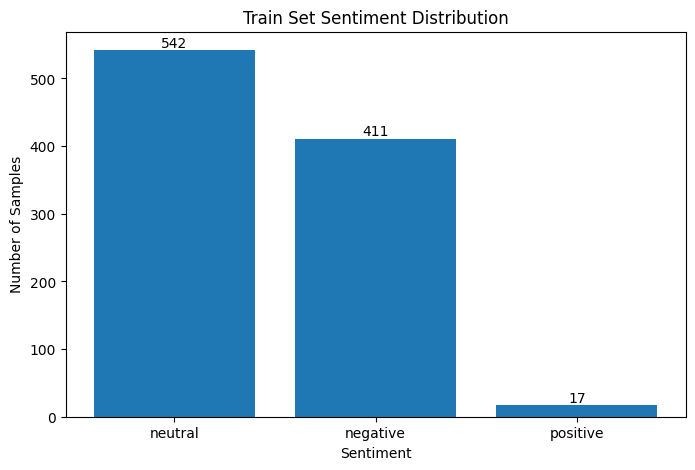


Test Set Sentiment Distribution class distribution:
customer_sentiment
negative    10
neutral     10
positive    10
Name: count, dtype: int64


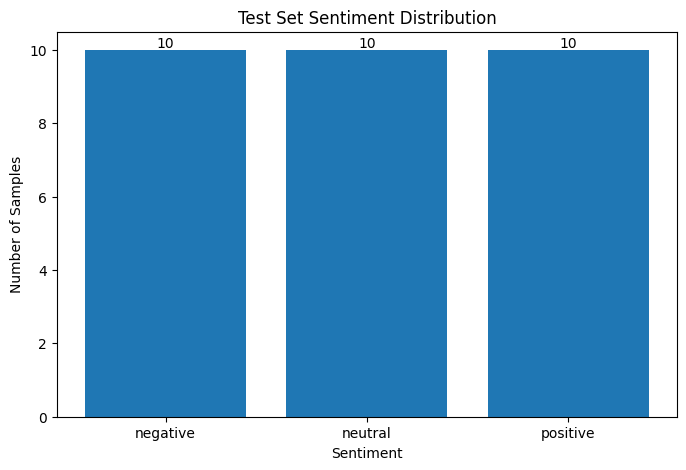

In [12]:
def plot_sentiment_distribution(df, title, label_col="customer_sentiment"):
    class_counts = df[label_col].value_counts()

    print(f"\n{title} class distribution:")
    print(class_counts)

    plt.figure(figsize=(8,5))
    bars = plt.bar(class_counts.index.astype(str), class_counts.values)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )

    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Samples")
    plt.show()

plot_sentiment_distribution(train_df, "Train Set Sentiment Distribution")
plot_sentiment_distribution(test_df, "Test Set Sentiment Distribution")

Conversation LEghts( To see if we need to normalize)

Train conversation length summary:
count     970.000000
mean     2129.284536
std       564.751035
min        46.000000
25%      1760.250000
50%      2058.500000
75%      2430.000000
max      5708.000000
Name: conversation_length, dtype: float64

Test conversation length summary:
count      30.000000
mean     2178.566667
std       828.185873
min      1125.000000
25%      1772.500000
50%      2092.500000
75%      2459.250000
max      5496.000000
Name: conversation_length, dtype: float64


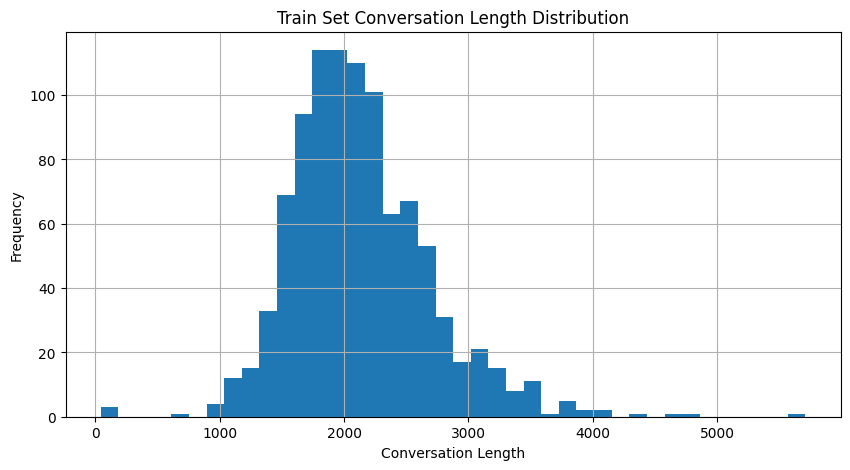

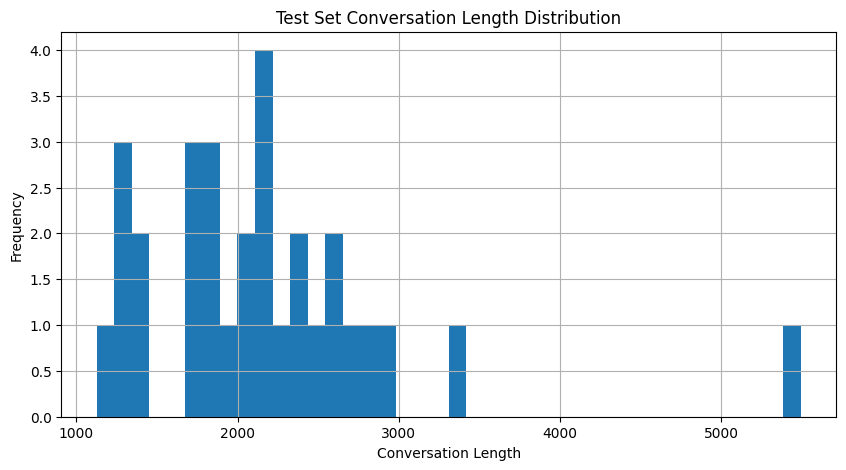

In [14]:
train_df["conversation_length"] = train_df["conversation"].astype(str).apply(len)
test_df["conversation_length"] = test_df["conversation"].astype(str).apply(len)

print("Train conversation length summary:")
print(train_df["conversation_length"].describe())

print("\nTest conversation length summary:")
print(test_df["conversation_length"].describe())


plt.figure(figsize=(10,5))
train_df["conversation_length"].hist(bins=40)
plt.title("Train Set Conversation Length Distribution")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
test_df["conversation_length"].hist(bins=40)
plt.title("Test Set Conversation Length Distribution")
plt.xlabel("Conversation Length")
plt.ylabel("Frequency")
plt.show()

Average conversation length by sentiment:
customer_sentiment
negative    2395.454988
neutral     1940.826568
positive    1702.705882
Name: conversation_length, dtype: float64


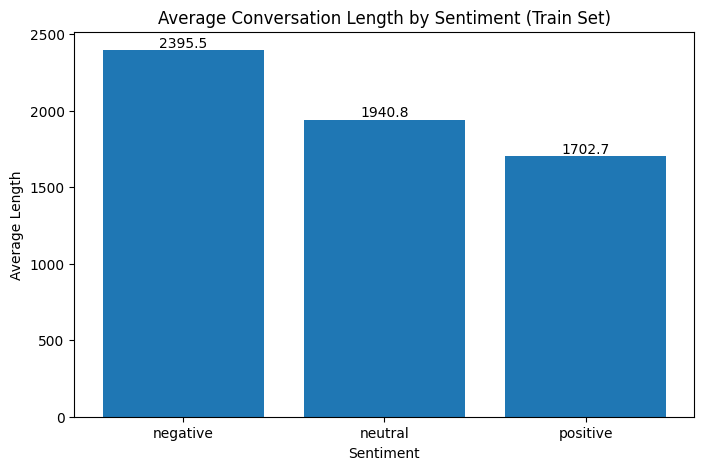

In [15]:
avg_len_by_sentiment = train_df.groupby("customer_sentiment")["conversation_length"].mean().sort_values(ascending=False)

print("Average conversation length by sentiment:")
print(avg_len_by_sentiment)

plt.figure(figsize=(8,5))
bars = plt.bar(avg_len_by_sentiment.index, avg_len_by_sentiment.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Conversation Length by Sentiment (Train Set)")
plt.xlabel("Sentiment")
plt.ylabel("Average Length")
plt.show()

Correlations

customer_sentiment         negative   neutral  positive
issue_area                                             
Cancellations and returns  0.490975  0.509025  0.000000
Login and Account          0.187919  0.812081  0.000000
Order                      0.604651  0.329457  0.065891
Shipping                   0.528571  0.471429  0.000000
Shopping                   0.318584  0.681416  0.000000
Warranty                   0.174757  0.825243  0.000000


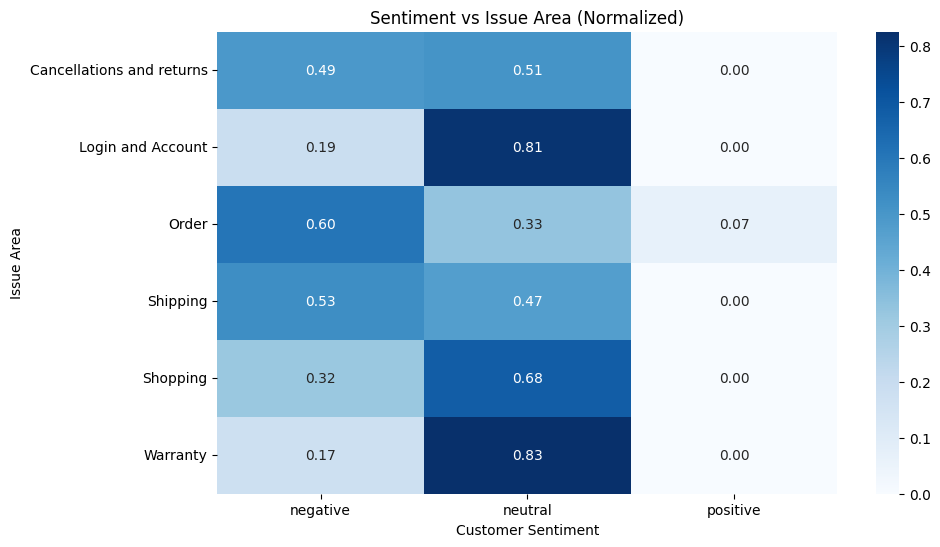

customer_sentiment  negative   neutral  positive
product_category                                
Appliances          0.418502  0.561674  0.019824
Electronics         0.416382  0.580205  0.003413
Men/Women/Kids      0.443946  0.524664  0.031390


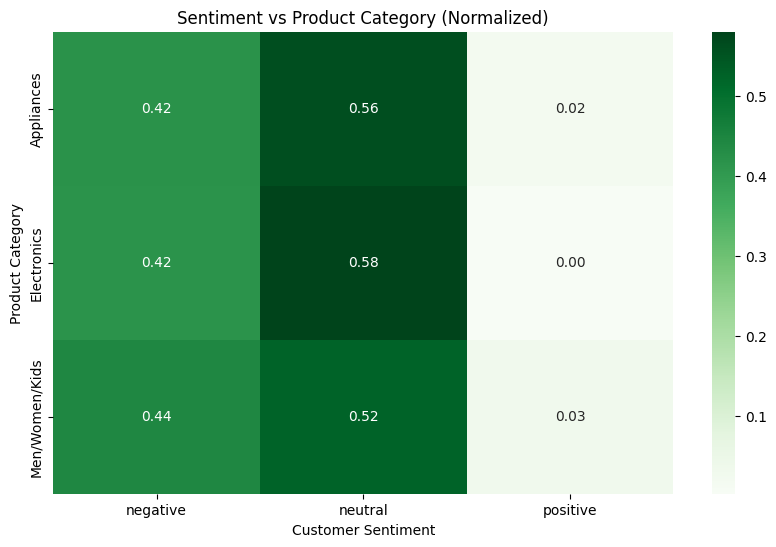

customer_sentiment  negative   neutral  positive
issue_complexity                                
high                0.475610  0.487805  0.036585
less                0.417373  0.567797  0.014831
medium              0.420673  0.562500  0.016827


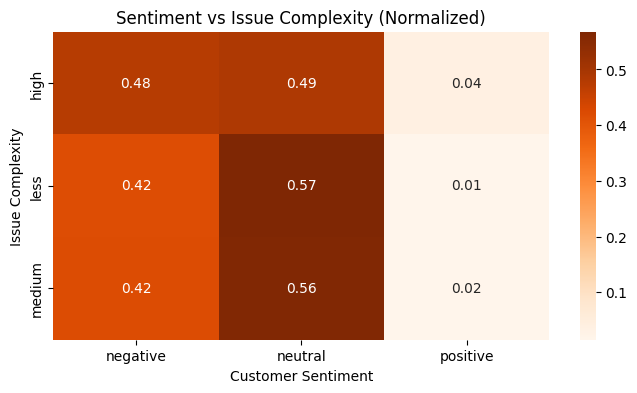

customer_sentiment      negative   neutral  positive
agent_experience_level                              
experienced             0.433628  0.554572  0.011799
inexperienced           0.333333  0.659574  0.007092
junior                  0.442857  0.532653  0.024490


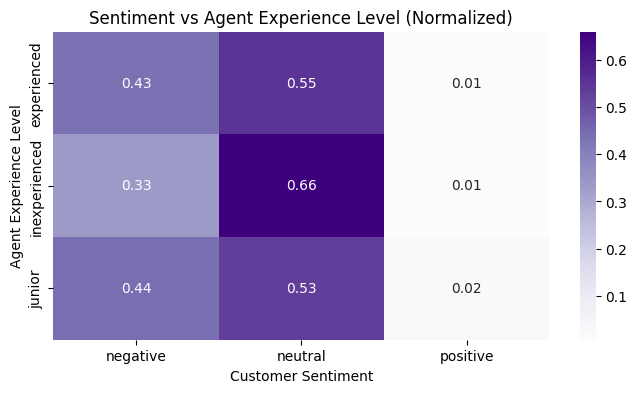

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
ct_issue_area = pd.crosstab(
    train_df["issue_area"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_issue_area)

plt.figure(figsize=(10,6))
sns.heatmap(ct_issue_area, annot=True, cmap="Blues", fmt=".2f")
plt.title("Sentiment vs Issue Area (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Issue Area")
plt.show()

ct_product = pd.crosstab(
    train_df["product_category"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_product)

plt.figure(figsize=(10,6))
sns.heatmap(ct_product, annot=True, cmap="Greens", fmt=".2f")
plt.title("Sentiment vs Product Category (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Product Category")
plt.show()

ct_complexity = pd.crosstab(
    train_df["issue_complexity"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_complexity)

plt.figure(figsize=(8,4))
sns.heatmap(ct_complexity, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Sentiment vs Issue Complexity (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Issue Complexity")
plt.show()

ct_agent = pd.crosstab(
    train_df["agent_experience_level"],
    train_df["customer_sentiment"],
    normalize="index"
)

print(ct_agent)

plt.figure(figsize=(8,4))
sns.heatmap(ct_agent, annot=True, cmap="Purples", fmt=".2f")
plt.title("Sentiment vs Agent Experience Level (Normalized)")
plt.xlabel("Customer Sentiment")
plt.ylabel("Agent Experience Level")
plt.show()